# DFT–OSA frequency/time pairing: beta2 = −0.03

Your goal is to complete the numerical functions and reproduce exactly three figures:

1. `frequency_time_pairing_beta2_-003_high_scale`
2. `peaks_linear_scale_onetoone_beta2_-003_high_scale`
3. `dft_statistics_beta2_-003_high_scale`

Compare your output with `reference_plots/`. Do not resample the DFT stack. Interpolate the OSA onto the final frequency coordinate of the 1,250 DFT samples.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import differential_evolution, linear_sum_assignment
from scipy.signal import find_peaks, resample

DATA_DIR = Path('data')
PLOT_DIR = Path('student_plots')
PLOT_DIR.mkdir(exist_ok=True)

STACK_FILE = DATA_DIR / 'beta2_-003.npy'
OSA_FILE = DATA_DIR / 'osa_reference_beta2_-003_phase.txt'
SCALE_LABELS = ['0.07 V/div', '0.015 V/div']
DT_NS = 0.010
C_NM_THz = 299792.458
OSA_WINDOW_NM = (1200.0, 1700.0)


## Exercise functions

Fill all eight `TODO` functions. Keep the signatures unchanged. Useful checks:

- The stack shape is `(2, 999, 1250)`.
- The high-scale index is recovered from the largest absolute voltage reached, not from the label order.
- The OSA input wavelength is in meters and its power is in dBm.
- Clip OSA values below −70 dBm, convert to mW, and sort by increasing frequency.
- Crop to 1200–1700 nm, then use `scipy.signal.resample` to make exactly 1,250 OSA points before fitting.
- Use the high-scale mean only for alignment and peak matching.
- A good final peak fit has (R^2 > 0.995).


In [2]:
def select_high_scale(stack_arr):
    """Return (high_scale_index, high_scale_shots, maximum_absolute_voltage_per_scale)."""
    # TODO: calculate max(abs(...)) over shots and time for each scale.

    max_abs_per_scale = np.max(np.abs(stack_arr), axis=(1, 2))
    high_scale_idx = int(np.argmax(max_abs_per_scale))
    return high_scale_idx, stack_arr[high_scale_idx], max_abs_per_scale

    raise NotImplementedError

def read_and_convert_osa(path, floor_dbm=-70.0):
    """Return wavelength_nm, frequency_thz, power_mw, power_dbm, sorted by frequency."""
    # TODO: read the two columns, convert wavelength and power, then sort.

    # Read text fileand skipping the row header ("wavelength power")
    data = np.loadtxt(path, skiprows=1)
    wl_m, p_dbm = data[:, 0], data[:, 1]

    # Convert wavelength (meters to nanometers) and calculate frequency
    wl_nm = wl_m * 1e9
    f_thz = C_NM_THz / wl_nm

    # Clip OSA power to floor and convert dBm to linear mW
    p_dbm_clipped = np.clip(p_dbm, a_min=floor_dbm, a_max=None)
    p_mw = 10 ** (p_dbm_clipped / 10.0)

    # Sort strictly by increasing frequency
    sort_idx = np.argsort(f_thz)

    return wl_nm[sort_idx], f_thz[sort_idx], p_mw[sort_idx], p_dbm_clipped[sort_idx]

    raise NotImplementedError


def dft_statistics(shots):
    """Return mean, standard deviation, pointwise minimum, and pointwise maximum."""
    # TODO: reduce only across the shot axis (axis=0).
    # Reduce across the shot axis (axis 0)
    mean_dft = np.mean(shots, axis=0)
    std_dft = np.std(shots, axis=0)
    min_dft = np.min(shots, axis=0)
    max_dft = np.max(shots, axis=0)
    return mean_dft, std_dft, min_dft, max_dft
    raise NotImplementedError


def resample_osa_for_fitting(wavelength_nm, power_mw, target_points):
    """Use scipy.signal.resample in wavelength order; return wavelength, frequency, power.

    Sort wavelength in ascending order first. Use the optional `t=` argument so
    SciPy returns the corresponding resampled wavelength coordinates. Clip small
    negative Fourier-resampling artifacts in linear power to zero, convert the
    wavelength grid to frequency, and finally sort all outputs by frequency.
    """
    #Sort wavelength in ascending order
    sort_wl = np.argsort(wavelength_nm)
    wl_asc = wavelength_nm[sort_wl]
    p_asc = power_mw[sort_wl]

    #Use scipy.signal.resample with the `t=` argument
    p_res, wl_res = resample(p_asc, target_points, t=wl_asc)

    #Clip small negative Fourier-resampling artifacts to zero
    p_res = np.clip(p_res, 0, None)

    #Convert the wavelength grid to frequency
    f_res = C_NM_THz / wl_res

    #sort outputs by frequency
    sort_f = np.argsort(f_res)
    return wl_res[sort_f], f_res[sort_f], p_res[sort_f]

    # TODO: resample OSA only. Never pass stack_arr or DFT shots to this function.
    raise NotImplementedError


def align_osa_to_dft(mean_dft, osa_frequency_thz, osa_power_mw):
    """Return an approximate frequency axis and OSA power on the unchanged DFT grid.

    Hint: optimize the start/end frequency inside the OSA window by maximizing
    correlation between smoothed, standardized DFT and interpolated OSA traces.
    Require a frequency span of 5–18 THz and at least 80% finite overlap.
    differential_evolution(..., seed=3, tol=1e-8) is deterministic here.
    """
    # TODO
    # Standardize and smooth the DFT using gaussian distribution (to remove electrical noise
    dft_smooth = gaussian_filter1d(mean_dft, sigma=2)
    dft_std = (dft_smooth - np.mean(dft_smooth)) / (np.std(dft_smooth) + 1e-12)
# frequency range of the recorded OSA data
    min_f, max_f = np.min(osa_frequency_thz), np.max(osa_frequency_thz)

    def objective(bounds):
        f_start, f_end = bounds
        span = f_end - f_start

        # Impose penalties for invalid spans or reversed axes
        if f_start >= f_end or span < 5 or span > 18:
            return 1e6

        test_f_axis = np.linspace(f_start, f_end, len(mean_dft))

        # Require 80% of the tested grid to fall inside the known OSA bounds
        finite_overlap = np.sum((test_f_axis >= min_f) & (test_f_axis <= max_f)) / len(test_f_axis)
        if finite_overlap < 0.9:
            return 1e6

        osa_interp = np.interp(test_f_axis, osa_frequency_thz, osa_power_mw, left=0, right=0)

        if np.std(osa_interp) == 0:
            return 1e6

        osa_std = (osa_interp - np.mean(osa_interp)) / np.std(osa_interp)

        # Maximize correlation -> minimize negative correlation
        corr = np.corrcoef(dft_std, osa_std)[0, 1]
        return -corr

    # Broad search bounds encompassing the typical 1200-1700nm window (176 - 250 THz) why 10 THz window???
    search_bounds = [(min_f - 2, max_f + 2), (min_f - 2, max_f + 2)]
    #optimizer
    res = differential_evolution(objective, search_bounds, seed=3, tol=1e-8)

    best_f_start, best_f_end = res.x
    approx_freq = np.linspace(best_f_start, best_f_end, len(mean_dft))
    approx_osa = np.interp(approx_freq, osa_frequency_thz, osa_power_mw, left=0, right=0)

    return approx_freq, approx_osa


    raise NotImplementedError


def pair_prominent_peaks(mean_dft, osa_on_dft_grid):
    """Return one-to-one arrays of DFT and OSA peak indices.

    Suggested settings: Gaussian sigma=2, prominence=1% of peak-to-peak range,
    distance=8. Use linear_sum_assignment on absolute index separation and retain
    pairs separated by no more than 20 samples.
    """
    # TODO
    # Smooth before peak finding as recommended
    dft_s = gaussian_filter1d(mean_dft, sigma=2)
    osa_s = gaussian_filter1d(osa_on_dft_grid, sigma=2)

    dft_prom = np.ptp(dft_s) * 0.01
    osa_prom = np.ptp(osa_s) * 0.01

    dft_peaks, _ = find_peaks(dft_s, prominence=dft_prom, distance=8)
    osa_peaks, _ = find_peaks(osa_s, prominence=osa_prom, distance=8)

    # Calculate distance matrix between all peak indices
    cost_matrix = np.abs(dft_peaks[:, None] - osa_peaks[None, :])

    # Match peaks one-to-one globally
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    # Enforce maximum shift tolerance of 20 samples
    valid_pairs = cost_matrix[row_ind, col_ind] <= 20

    return dft_peaks[row_ind[valid_pairs]], osa_peaks[col_ind[valid_pairs]]
    raise NotImplementedError


def frequency_time_fit(time_ns, dft_peak_indices, osa_peak_indices, approximate_frequency_axis):
    """Return slope/intercept, R², final frequency axis, and final wavelength axis."""
    # TODO: np.polyfit paired frequency versus DFT peak time; calculate R².
    paired_t = time_ns[dft_peak_indices]
    paired_f = approximate_frequency_axis[osa_peak_indices]

    # Compute 1st order (linear) polynomial fit
    coef = np.polyfit(paired_t, paired_f, 1)
    f_pred = np.polyval(coef, paired_t)

    # Calculate R-squared value
    ss_res = np.sum((paired_f - f_pred) ** 2)
    ss_tot = np.sum((paired_f - np.mean(paired_f)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    # Generate continuous axes mapped to the oscilloscope grid
    final_freq = np.polyval(coef, time_ns)
    final_wl = C_NM_THz / final_freq

    return coef, r2, final_freq, final_wl
    raise NotImplementedError


def resample_osa_to_dft(osa_frequency_thz, osa_power_mw, final_frequency_axis):
    """Interpolate OSA only; output length must equal the number of DFT samples."""
    # TODO: use np.interp with NaN outside the OSA range.
    return np.interp(final_frequency_axis, osa_frequency_thz, osa_power_mw, left=np.nan, right=np.nan)
    raise NotImplementedError


## Run your analysis

This cell must use only the automatically detected high-scale stack for frequency/time matching.


In [3]:
stack_arr = np.load(STACK_FILE)
high_index, high_shots, scale_maxima = select_high_scale(stack_arr)
mean_dft, std_dft, min_dft, max_dft = dft_statistics(high_shots)
time_ns = np.arange(mean_dft.size) * DT_NS

wavelength_nm, osa_frequency, osa_mw, osa_dbm = read_and_convert_osa(OSA_FILE)
lo, hi = OSA_WINDOW_NM
inside = (wavelength_nm >= lo) & (wavelength_nm <= hi)
fit_wavelength, fit_frequency, fit_osa_mw = resample_osa_for_fitting(
    wavelength_nm[inside], osa_mw[inside], mean_dft.size
)
approx_frequency, approx_osa = align_osa_to_dft(mean_dft, fit_frequency, fit_osa_mw)
dft_peaks, osa_peaks = pair_prominent_peaks(mean_dft, approx_osa)
coefficients, r2, frequency_axis, wavelength_axis = frequency_time_fit(
    time_ns, dft_peaks, osa_peaks, approx_frequency
)
osa_resampled = resample_osa_to_dft(fit_frequency, fit_osa_mw, frequency_axis)

assert high_shots.shape == (999, 1250)
assert len(osa_resampled) == high_shots.shape[-1]
assert len(fit_osa_mw) == high_shots.shape[-1]
assert r2 > 0.995
print('High scale:', SCALE_LABELS[high_index], '| maxima:', scale_maxima)
print('f(t) coefficients:', coefficients, '| R²:', r2)


High scale: 0.07 V/div | maxima: [0.70838906 0.15179766]
f(t) coefficients: [  1.22090507 185.34657641] | R²: 0.9959404689987806


## Plotting helpers

The plotting code is supplied. Your numerical functions determine whether these reproduce the references.


In [4]:
STYLE = {'wide': (9.5 / 2.54, 5 / 2.54), 'font': 8, 'legend': 6, 'dpi': 300}
TAG = 'beta2_-003_high_scale'

def save_figure(fig, stem):
    for suffix in ('png', 'svg'):
        fig.savefig(PLOT_DIR / f'{stem}.{suffix}', dpi=STYLE['dpi'], bbox_inches='tight')
    plt.show()

def add_top_axis(ax):
    top = ax.twiny(); top.set_xlim(ax.get_xlim())
    idx = np.linspace(0, time_ns.size - 1, 5).astype(int)
    top.set_xticks(time_ns[idx])
    top.set_xticklabels([f'{wavelength_axis[i] / 1000:.3f}' for i in idx], fontsize=STYLE['font'])
    top.set_xlabel(r'Wavelength [$\mu$m]', fontsize=STYLE['font'])


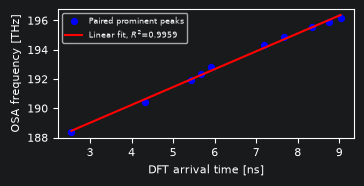

In [5]:
# Plot 1: frequency_time_pairing
paired_time = time_ns[dft_peaks]
paired_frequency = approx_frequency[osa_peaks]
fig, ax = plt.subplots(figsize=STYLE['wide'])
ax.scatter(paired_time, paired_frequency, s=18, color='blue', label='Paired prominent peaks')
order = np.argsort(paired_time)
ax.plot(paired_time[order], np.polyval(coefficients, paired_time[order]), color='red',
        label=fr'Linear fit, $R^2$={r2:.4f}')
ax.set_xlabel('DFT arrival time [ns]', fontsize=STYLE['font'])
ax.set_ylabel('OSA frequency [THz]', fontsize=STYLE['font'])
ax.tick_params(labelsize=STYLE['font']); ax.legend(fontsize=STYLE['legend'])
fig.tight_layout(); save_figure(fig, f'frequency_time_pairing_{TAG}')


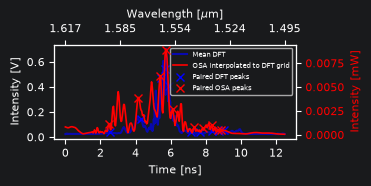

In [6]:
# Plot 2: peaks_linear_scale_onetoone
fig, ax = plt.subplots(figsize=STYLE['wide'])
dft_line, = ax.plot(time_ns, mean_dft, color='blue', alpha=0.65, label='Mean DFT')
dft_marks, = ax.plot(time_ns[dft_peaks], mean_dft[dft_peaks], 'x', color='blue', label='Paired DFT peaks')
ax.set_xlabel('Time [ns]', fontsize=STYLE['font']); ax.set_ylabel('Intensity [V]', fontsize=STYLE['font'])
ax.tick_params(labelsize=STYLE['font'])
right = ax.twinx()
osa_line, = right.plot(time_ns, osa_resampled, color='red', linewidth=1.2, label='OSA interpolated to DFT grid')
osa_marks, = right.plot(time_ns[osa_peaks], osa_resampled[osa_peaks], 'x', color='red', label='Paired OSA peaks')
right.set_ylabel('Intensity [mW]', fontsize=STYLE['font'], color='red')
right.tick_params(axis='y', labelcolor='red', labelsize=STYLE['font'])
add_top_axis(ax)
ax.legend(handles=[dft_line, osa_line, dft_marks, osa_marks], loc='upper right', fontsize=5)
fig.tight_layout(); save_figure(fig, f'peaks_linear_scale_onetoone_{TAG}')


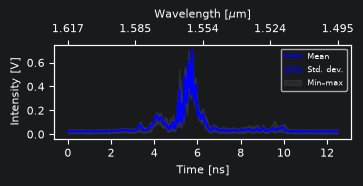

In [7]:
# Plot 3: dft_statistics
fig, ax = plt.subplots(figsize=STYLE['wide'])
ax.plot(time_ns, mean_dft, color='blue', label='Mean')
ax.fill_between(time_ns, mean_dft - std_dft, mean_dft + std_dft, color='blue', alpha=0.30, label='Std. dev.')
ax.fill_between(time_ns, min_dft, max_dft, color='gray', alpha=0.15, label='Min–max')
ax.set_xlabel('Time [ns]', fontsize=STYLE['font']); ax.set_ylabel('Intensity [V]', fontsize=STYLE['font'])
ax.tick_params(labelsize=STYLE['font']); add_top_axis(ax); ax.legend(fontsize=STYLE['legend'])
fig.tight_layout(); save_figure(fig, f'dft_statistics_{TAG}')


## Submission checklist

- All eight `TODO` functions are implemented without changing their signatures.
- Only the high-scale stack is used for OSA alignment and frequency/time peak matching.
- `stack_arr` remains `(2, 999, 1250)` and the high-scale shots remain `(999, 1250)`.
- The 1200–1700 nm OSA window is resampled to exactly 1,250 points before fitting.
- The fitted relation is linear and has (R^2 > 0.995).
- All three plots are saved as PNG and SVG in `student_plots/`.
